In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df1 = pd.read_csv(f'data\AEP_hourly.csv', index_col='Datetime')
df2 = pd.read_csv(f'data\COMED_hourly.csv', index_col='Datetime')
df3 = pd.read_csv(f'data\DAYTON_hourly.csv', index_col='Datetime')
df4 = pd.read_csv(f'data\DEOK_hourly.csv', index_col='Datetime')
df5 = pd.read_csv(f'data\DOM_hourly.csv', index_col='Datetime')
df6 = pd.read_csv(f'data\DUQ_hourly.csv', index_col='Datetime')
df7 = pd.read_csv(f'data\EKPC_hourly.csv', index_col='Datetime')
df8 = pd.read_csv(f'data\FE_hourly.csv', index_col='Datetime')
df9 = pd.read_csv(r'data\NI_hourly.csv', index_col='Datetime')
df10 = pd.read_csv(f'data\PJME_hourly.csv', index_col='Datetime')
df11 = pd.read_csv(f'data\PJMW_hourly.csv', index_col='Datetime')

df_final = df1.join([df2,df3,df4,df5,df6,df7,df8,df9,df10,df11])

# print first five row
df_final.head()

,AEP_MW,COMED_MW,DAYTON_MW,DEOK_MW,DOM_MW,DUQ_MW,EKPC_MW,FE_MW,NI_MW,PJME_MW,PJMW_MW
Datetime,,,,,,,,,,,
2004-12-31 01:00:00,13478.0,NaN,1596.0,NaN,NaN,NaN,NaN,NaN,9810.0,27160.0,5285.0
2004-12-31 02:00:00,12865.0,NaN,1517.0,NaN,NaN,NaN,NaN,NaN,9001.0,25791.0,5085.0
2004-12-31 03:00:00,12577.0,NaN,1486.0,NaN,NaN,NaN,NaN,NaN,8509.0,25052.0,4944.0
2004-12-31 04:00:00,12517.0,NaN,1469.0,NaN,NaN,NaN,NaN,NaN,8278.0,24797.0,4916.0
2004-12-31 05:00:00,12670.0,NaN,1472.0,NaN,NaN,NaN,NaN,NaN,8089.0,25026.0,4960.0


In [3]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 125361 entries, 2004-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   AEP_MW     125361 non-null  float64
 1   COMED_MW   70583 non-null   float64
 2   DAYTON_MW  125361 non-null  float64
 3   DEOK_MW    61825 non-null   float64
 4   DOM_MW     120275 non-null  float64
 5   DUQ_MW     123154 non-null  float64
 6   EKPC_MW    49421 non-null   float64
 7   FE_MW      66960 non-null   float64
 8   NI_MW      54778 non-null   float64
 9   PJME_MW    125361 non-null  float64
 10  PJMW_MW    125361 non-null  float64
dtypes: float64(11)
memory usage: 11.5+ MB


The AEP means American Electric Power and this dataframe refers to the whole American Consumption. <br>
Each an every of the other dataframes refer to different cities.

In [4]:
df_final.describe()

,AEP_MW,COMED_MW,DAYTON_MW,DEOK_MW,DOM_MW,DUQ_MW,EKPC_MW,FE_MW,NI_MW,PJME_MW,PJMW_MW
count,125361.000000,70583.000000,125361.000000,61825.000000,120275.000000,123154.000000,49421.000000,66960.000000,54778.000000,125361.000000,125361.000000
mean,15363.077847,11237.756174,2017.668996,3041.597541,10845.028119,1642.043401,1435.357722,7663.627688,11713.761236,31759.038983,5531.513541
std,2661.589281,2357.022834,402.920846,637.299488,2438.253016,310.399093,382.815695,1386.468697,2363.414180,6643.720256,1008.678744
min,9581.000000,7237.000000,982.000000,907.000000,1253.000000,1014.000000,514.000000,0.000000,7003.000000,14544.000000,2553.000000
25%,13416.000000,9496.000000,1716.000000,2594.000000,9154.000000,1423.000000,1153.000000,6608.000000,9981.000000,27103.000000,4788.000000
50%,15206.000000,11018.000000,1994.000000,2971.000000,10402.000000,1618.000000,1365.000000,7606.000000,11530.000000,31182.000000,5447.000000
75%,17121.000000,12397.000000,2267.000000,3409.000000,12287.500000,1811.000000,1667.000000,8483.000000,12891.000000,35451.000000,6199.000000
max,25695.000000,23753.000000,3746.000000,5445.000000,21651.000000,3054.000000,3490.000000,14032.000000,23631.000000,62009.000000,9594.000000


In [5]:
print(f'The minimum Datetime observed is: {df_final.index.min()}')
print(f'The maximum Datetime observed is: {df_final.index.max()}')

The minimum Datetime observed is: 2004-10-01 01:00:00
The maximum Datetime observed is: 2018-08-03 00:00:00


Text(0.5, 1.0, 'PJM Energy Consumption')

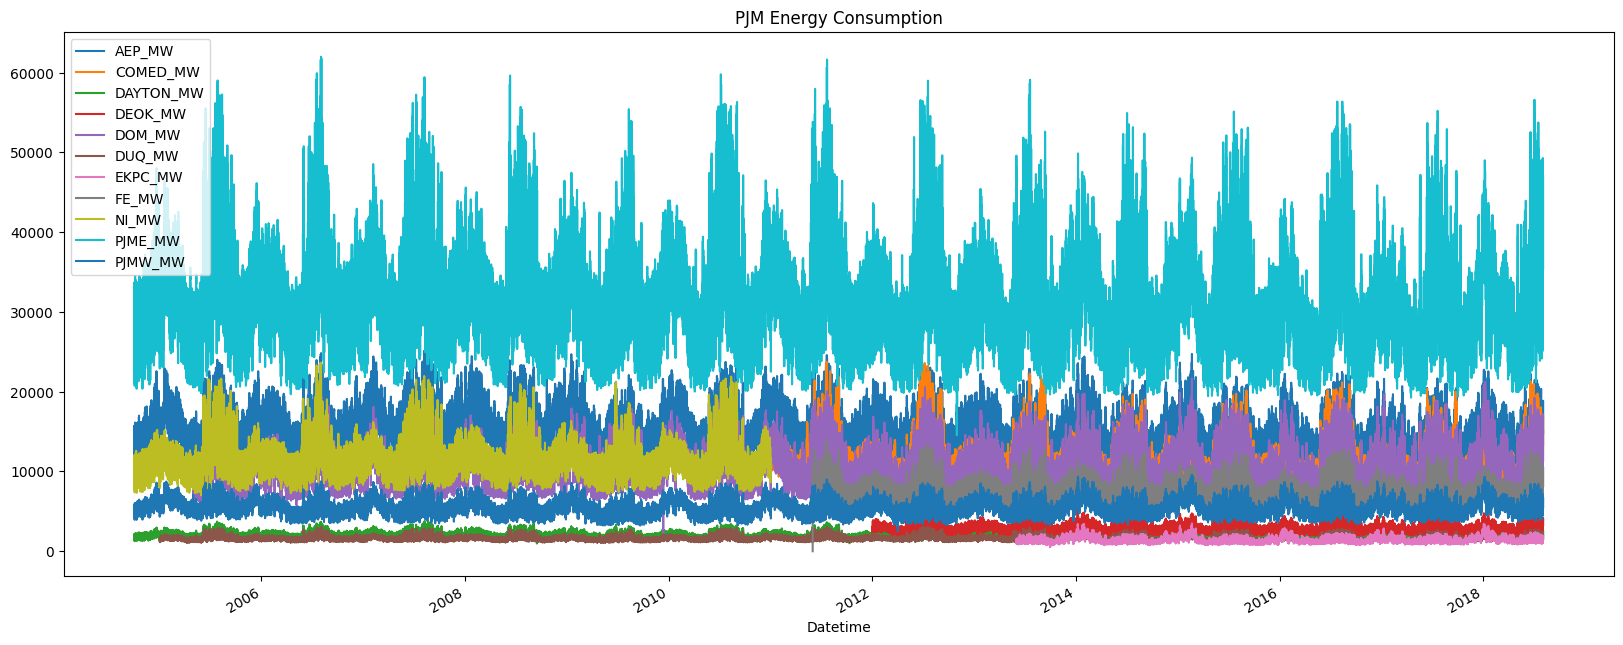

In [6]:
df_final= df_final.sort_index()

df_final.index = pd.to_datetime(df_final.index)

df_final.plot(figsize=(20,8))
plt.title('PJM Energy Consumption')

As we can see from the last plot we cannot make any knowledge (plot is completely messy).

Text(0.5, 1.0, 'PJM Energy Consumption for 2018')

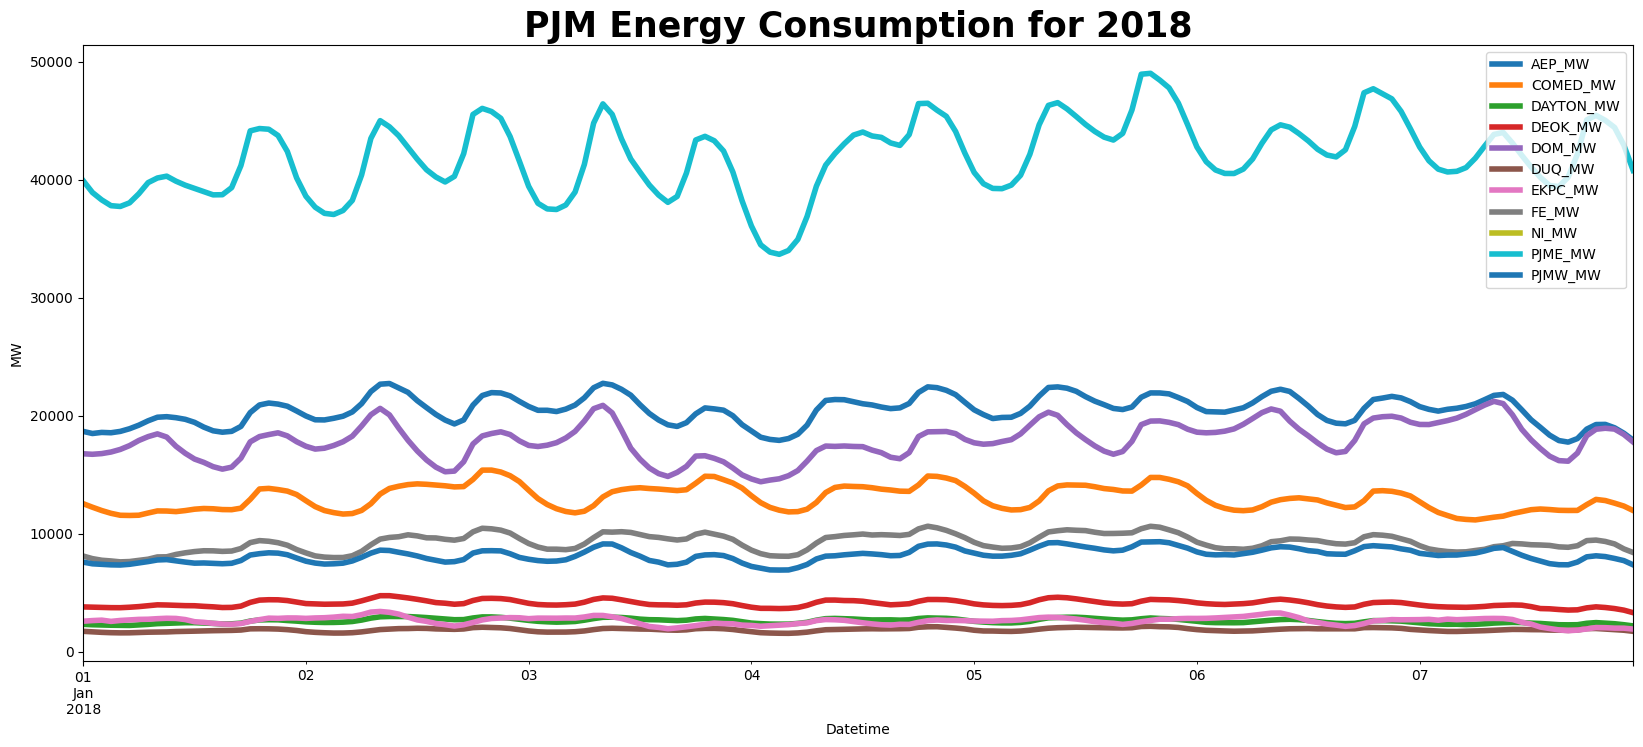

In [7]:
df_2018 = df_final[(df_final.index>='2018-01-01')& (df_final.index < '2018-01-08')]
df_2018.plot(figsize=(20,8),lw=4)
plt.ylabel('MW')
plt.title('PJM Energy Consumption for 2018', weight='bold', fontsize=25)

In [8]:
df_final.isnull().sum()

AEP_MW           0
COMED_MW     54778
DAYTON_MW        0
DEOK_MW      63536
DOM_MW        5086
DUQ_MW        2207
EKPC_MW      75940
FE_MW        58401
NI_MW        70583
PJME_MW          0
PJMW_MW          0
dtype: int64

In [9]:
df_final['Hour'] = df_final.index.hour
df_final['Month'] = df_final.index.month
df_final['Year'] = df_final.index.year
df_final['Day'] = df_final.index.day

In [10]:
df_final.head()

,AEP_MW,COMED_MW,DAYTON_MW,DEOK_MW,DOM_MW,DUQ_MW,EKPC_MW,FE_MW,NI_MW,PJME_MW,PJMW_MW,Hour,Month,Year,Day
Datetime,,,,,,,,,,,,,,,
2004-10-01 01:00:00,12379.0,NaN,1621.0,NaN,NaN,NaN,NaN,NaN,9305.0,24025.0,4628.0,1,10,2004,1
2004-10-01 02:00:00,11935.0,NaN,1536.0,NaN,NaN,NaN,NaN,NaN,8681.0,22845.0,4520.0,2,10,2004,1
2004-10-01 03:00:00,11692.0,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,8314.0,22138.0,4431.0,3,10,2004,1
2004-10-01 04:00:00,11597.0,NaN,1434.0,NaN,NaN,NaN,NaN,NaN,8094.0,21922.0,4383.0,4,10,2004,1
2004-10-01 05:00:00,11681.0,NaN,1489.0,NaN,NaN,NaN,NaN,NaN,8041.0,22193.0,4460.0,5,10,2004,1


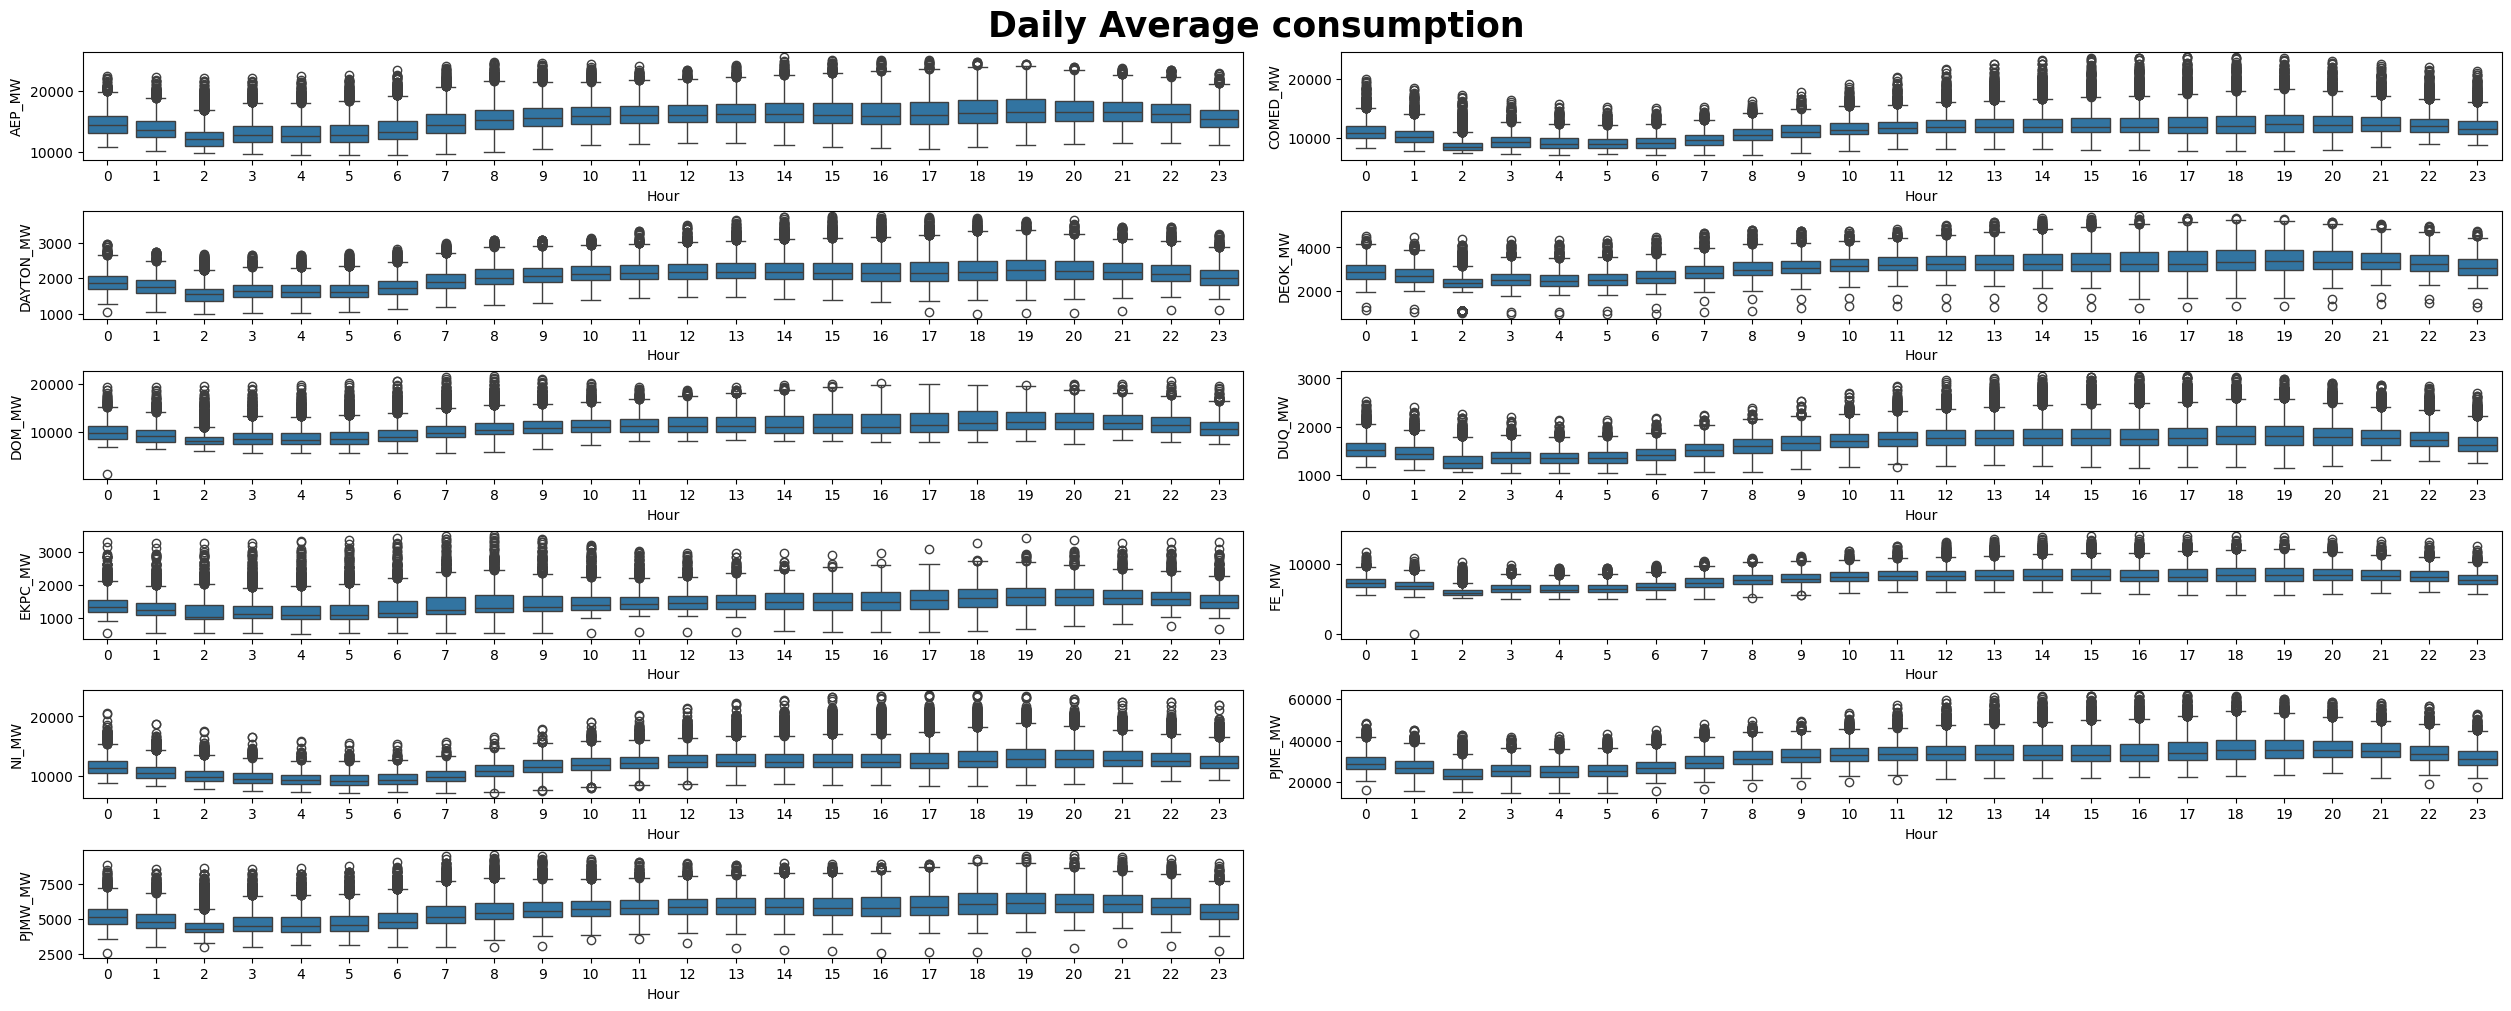

In [11]:
columns = ['AEP_MW', 'COMED_MW', 'DAYTON_MW', 'DEOK_MW', 'DOM_MW', 'DUQ_MW',
           'EKPC_MW', 'FE_MW', 'NI_MW', 'PJME_MW', 'PJMW_MW']

df_final = df_final.reset_index(drop=True)

fig, ax = plt.subplots(nrows = 6, ncols = 2, figsize = (25,10),constrained_layout = True)
fig.suptitle('Daily Average consumption', weight = 'bold',fontsize=25)
fig.delaxes(ax[5][1])
ax = ax.flatten()

for i,col in enumerate(columns):
    sns.boxplot(data = df_final, x = "Hour", y=col, ax = ax[i])

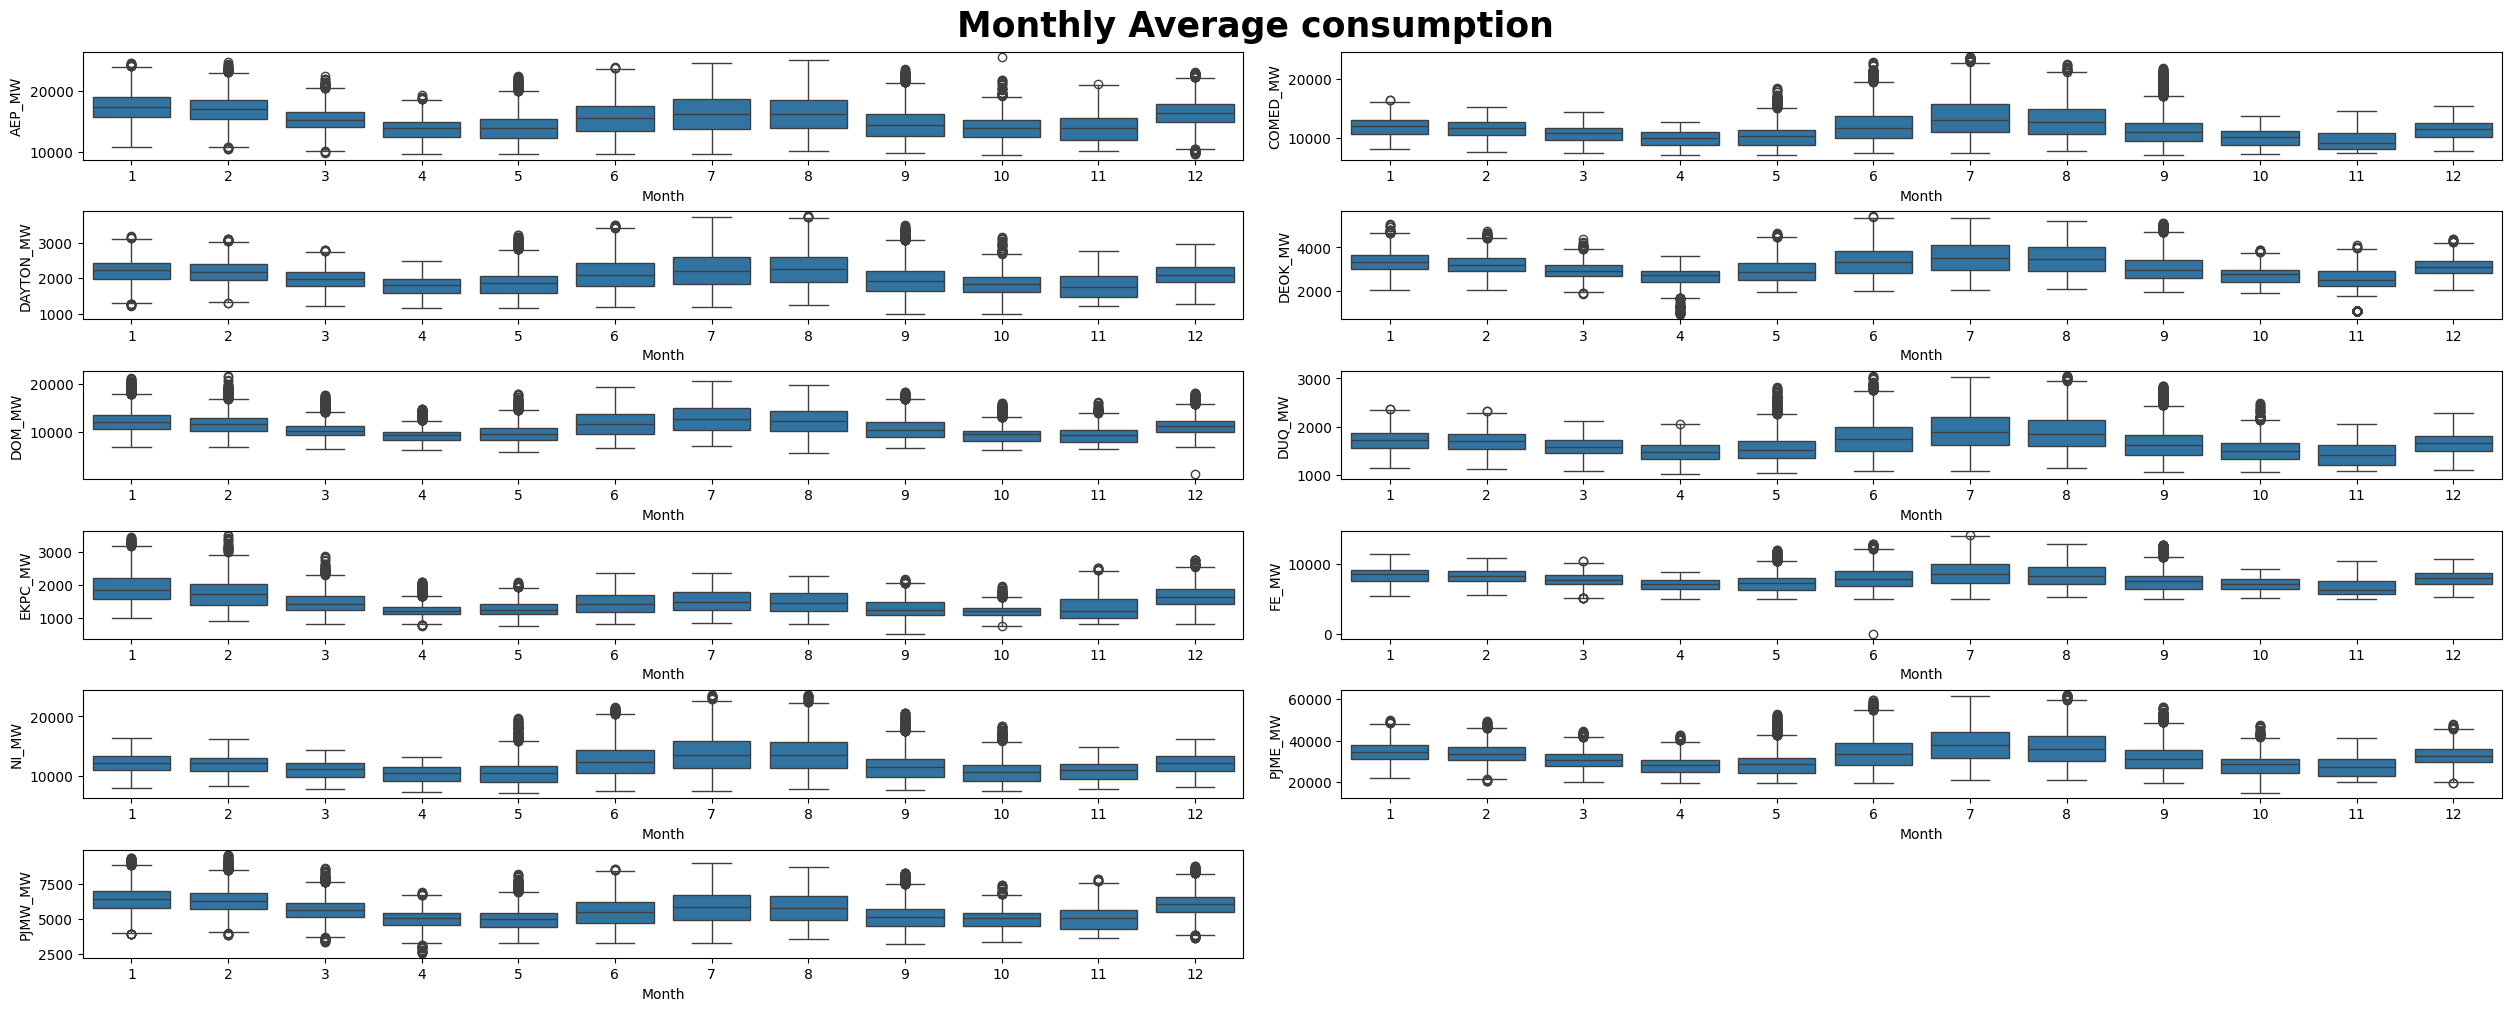

In [12]:
fig, ax = plt.subplots(nrows = 6, ncols = 2, figsize = (25,10),constrained_layout = True)
fig.suptitle('Monthly Average consumption', weight = 'bold',fontsize=25)
fig.delaxes(ax[5][1])
ax = ax.flatten()

for i,col in enumerate(columns):
    sns.boxplot(data = df_final, x = "Month", y=col, ax = ax[i])

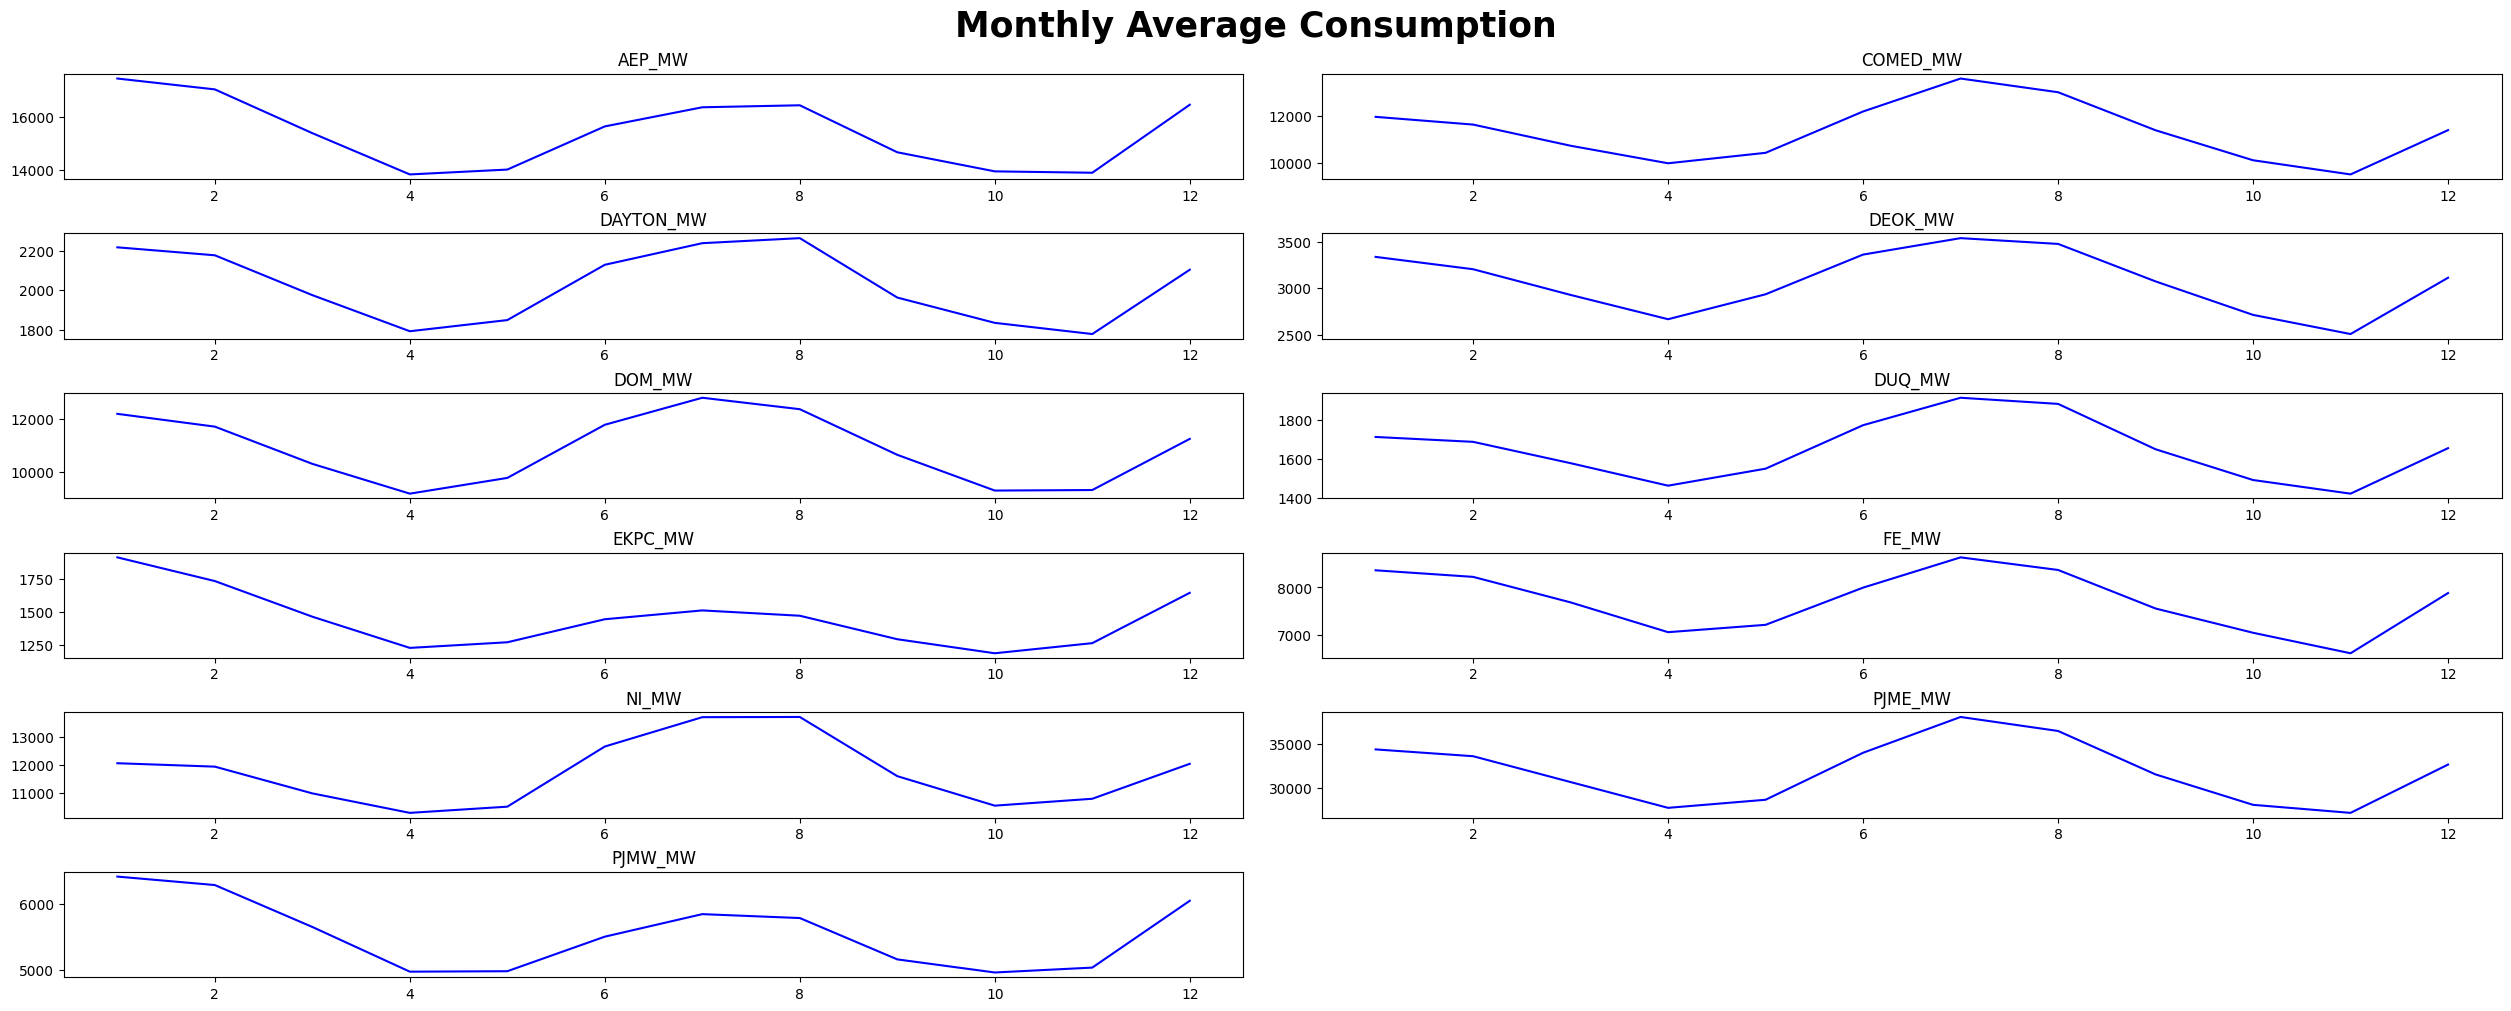

In [13]:
fig, ax = plt.subplots(nrows=6, ncols=2, figsize=(25,10), constrained_layout=True)
fig.suptitle('Monthly Average Consumption', weight='bold', fontsize=25)

ax = ax.flatten()
fig.delaxes(ax[-1])

df_monthly = df_final.groupby("Month")[columns].mean()
df_monthly = df_monthly.sort_index()

for i, col in enumerate(columns):
    ax[i].plot(df_monthly.index, df_monthly[col], color='blue')
    ax[i].set_title(col)

We can see that the time series during the months there are seasonal data.

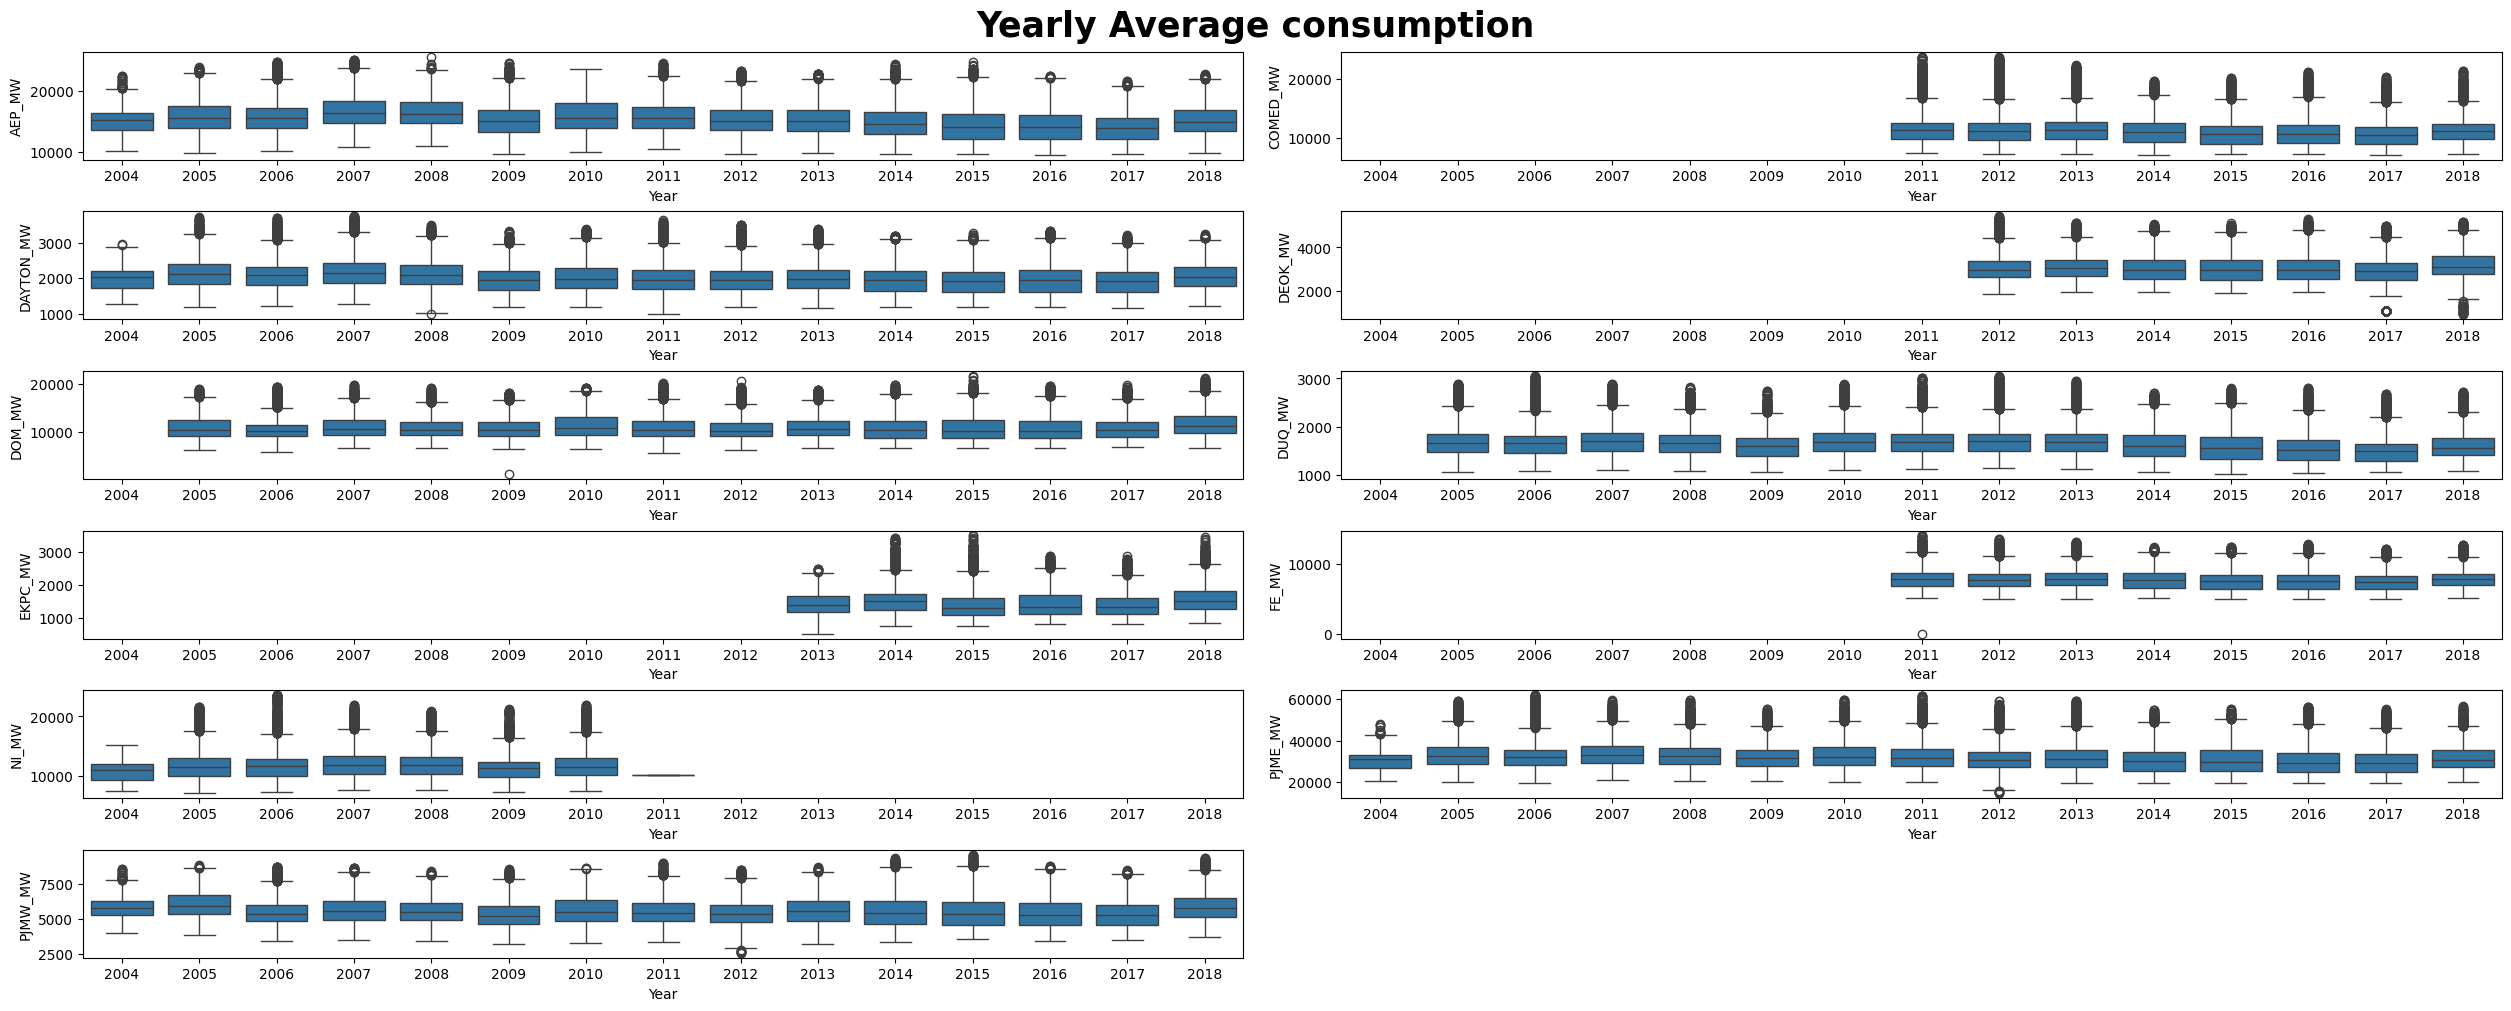

In [14]:
fig, ax = plt.subplots(nrows = 6, ncols = 2, figsize = (25,10),constrained_layout = True)
fig.suptitle('Yearly Average consumption', weight = 'bold',fontsize=25)
fig.delaxes(ax[5][1])
ax = ax.flatten()

for i,col in enumerate(columns):
    sns.boxplot(data = df_final, x = "Year", y=col, ax = ax[i])

So the null data for few of the columns are that they dont have data for some of the years.

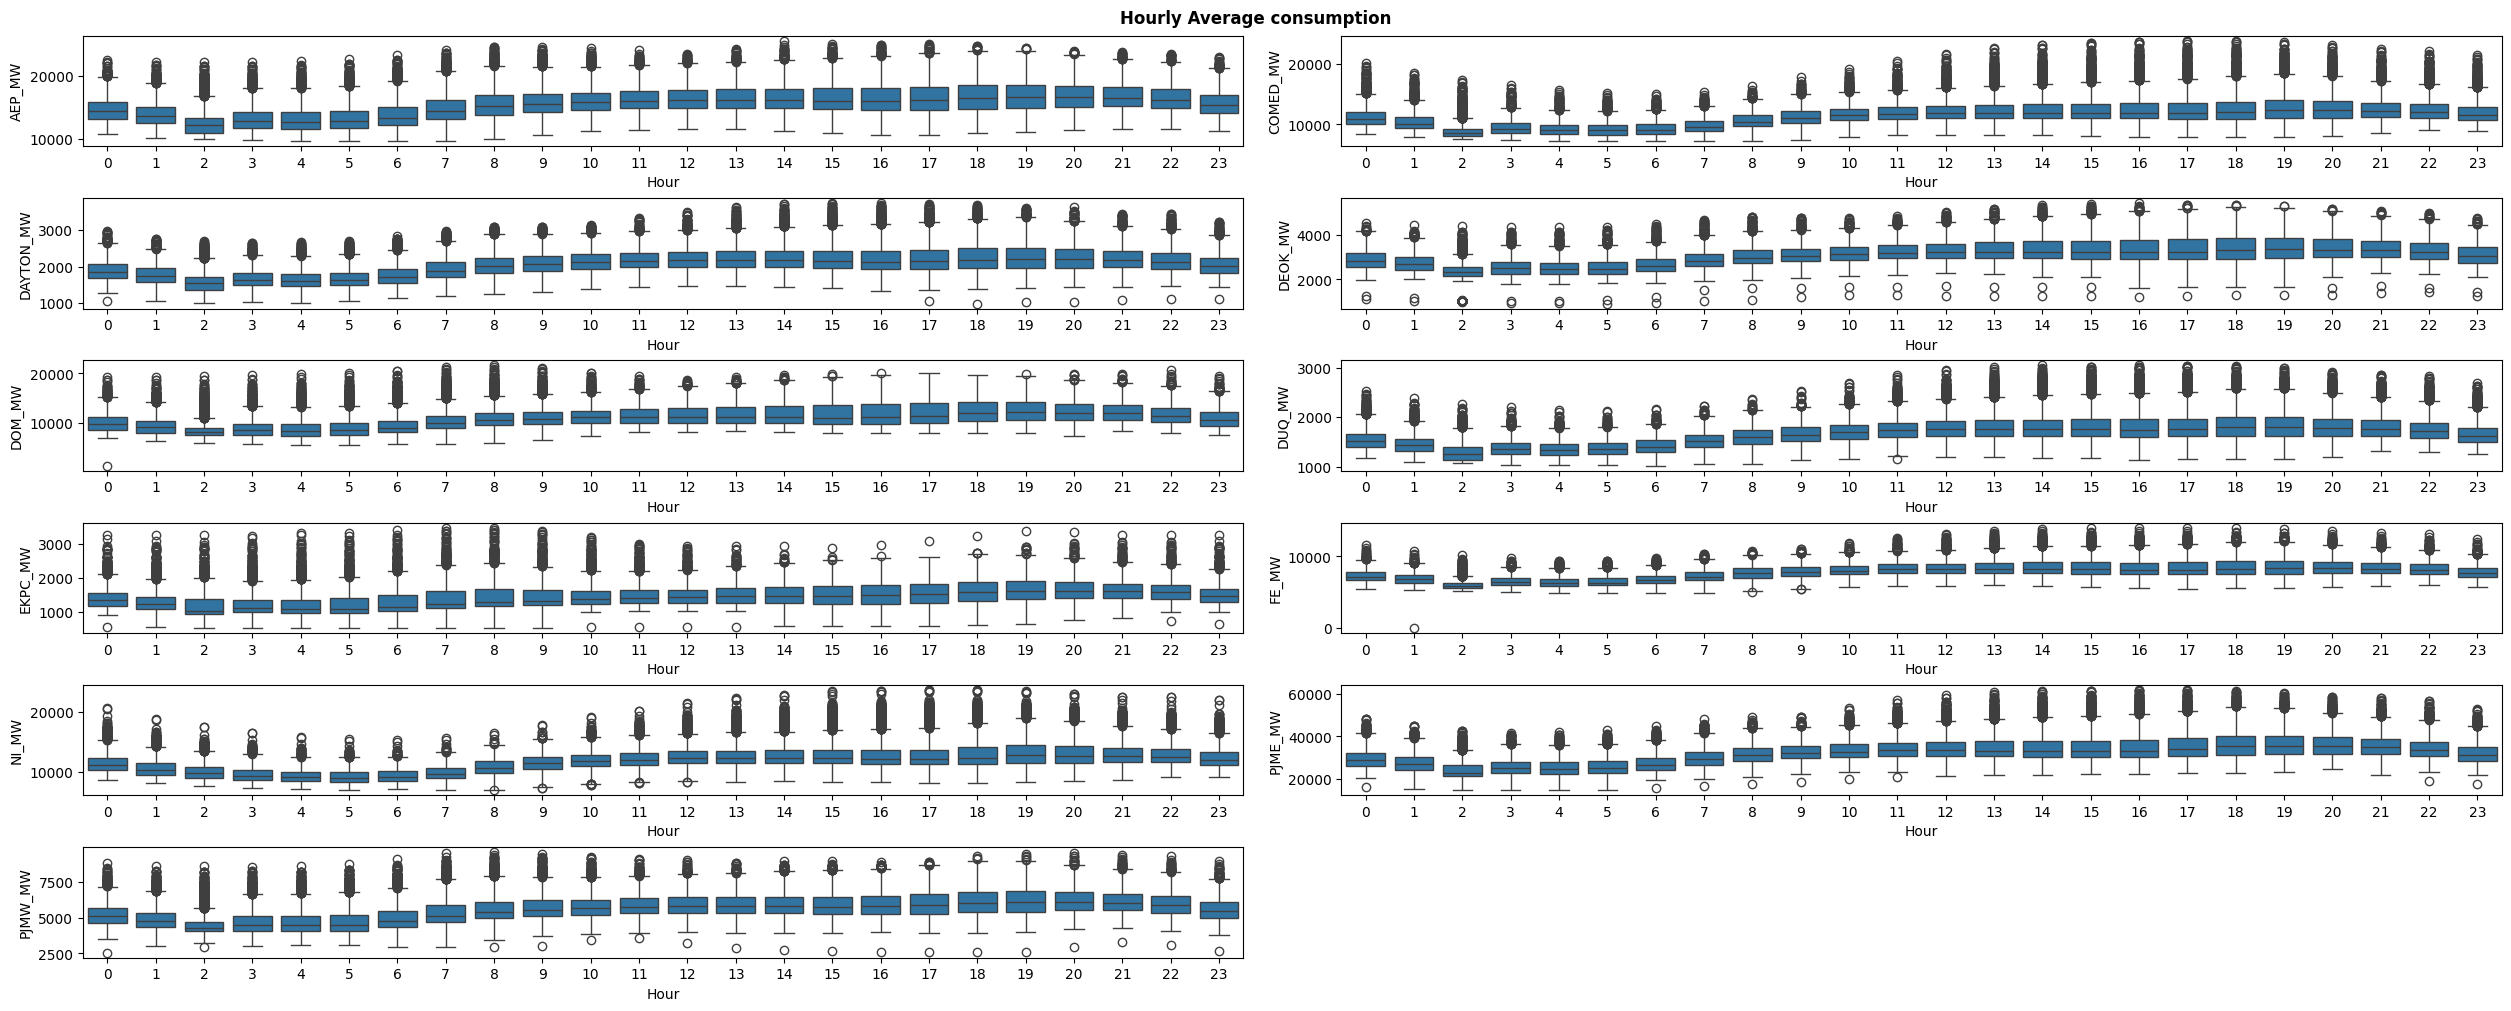

In [15]:
fig, ax = plt.subplots(nrows = 6, ncols = 2, figsize = (25,10),constrained_layout = True)
fig.suptitle('Hourly Average consumption', weight = 'bold')
fig.delaxes(ax[5][1])
ax = ax.flatten()

for i,col in enumerate(columns):
    sns.boxplot(data = df_final, x = "Hour", y=col, ax = ax[i])

I will use the dataframe only for the Dayton mw since the analysis after that will have the same logic as this.

In [35]:
# Dayton_mw df is the df3
df = df3
df.head()


,DAYTON_MW
Datetime,
2004-12-31 01:00:00,1596.0
2004-12-31 02:00:00,1517.0
2004-12-31 03:00:00,1486.0
2004-12-31 04:00:00,1469.0
2004-12-31 05:00:00,1472.0


In [44]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# The data that we are going to use (DAYTON)
df.head()

,DAYTON_MW
Datetime,
2004-10-01 01:00:00,1621.0
2004-10-01 02:00:00,1536.0
2004-10-01 03:00:00,1500.0
2004-10-01 04:00:00,1434.0
2004-10-01 05:00:00,1489.0


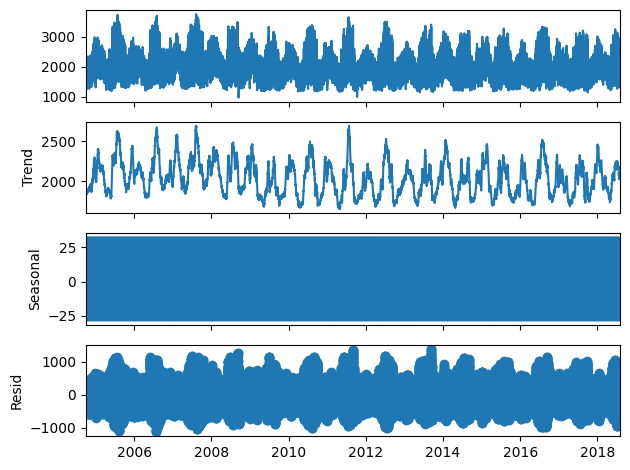

In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose
seasonal_decompose(df, period=365).plot()
plt.show()